<table>
    <tr>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/logo_ECI.png" width="300"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:blue;text-align:center">    <FONT COLOR="blue">  Redes Neuronales </p> Arquitectura en Tensorflow </p>     </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Machine Learning 1</p></tp>
            <tp><p style="font-size:115%;text-align:center">Pregrado MACC 2026-1</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Fabián Sánchez</p></tp>
        </td>
    </tr>
</table>

# <FONT SIZE=5 COLOR="purple"> 1. Introducción redes neuronales </FONT>

En este notebook haremos una introducción a los conceptos fundamentales de las redes neuronales y exploraremos un ejemplo ilustrativo con un conjunto de datos estructurado con el fin de revisar como generar la arquitectura de la red neuronal usando el perceptron multicapa de *skilearn* y luego con la librería *keras* y *tensorflow*. En un próximo notebook trabajaremos con *pytorch*

Iniciaremos indicando los conceptos fundamentales.

- Las redes neuronales artificiales o (ANN, artificial neural networks) son algoritmos de machine learning cuyo funcionamiento está inspirado en el funcionamiento de la neurona biológica y sus conexiones entre si.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/86206b1c9e9fe0b3caac025f9abfb1c0c526d973/Redes/neurona_vs_redes.png?raw=true" width="700" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración con Chat GPT   </FONT> <figcaption></center>
<br>


- La estructura de una red neuronal tiene la siguiente forma

     - Capa de entrada
     - Capas ocultas intermedias
     - Capa de salida


<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/Redes/redes3.png?raw=true" width="700" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia </FONT> <figcaption></center>
<br>


Cada una de estas capas está compuesta por nodos o neuronas que se conectan con otras y tienen asociadas pesos $w_{ij}$ y un umbral o bias $b_{ij}$.

Cuando la salida de cualquier nodo está por encima del valor de umbral determinado, ese nodo se activa y envía datos de salida a la siguiente capa de la red. En caso contrario, no se pasan datos a la siguiente capa.







## <FONT SIZE=4 COLOR="blue"> 1.2 Función de Activación </FONT>

Observe que un elemento importante que lleva a que se active o no una determinada neurona para tomar una decisión es la función de activación.

**Función de activación:** Es una función que transmite la información generada por la combinación lineal de pesos y entradas

$$a_1w_1+a_2w_2 + \dots + a_nw_n$$

Pensémoslo de la siguiente forma: si hemos definido un determinado umbral en una neurona, la función de activación al ser evaluada en la combinación lineal de pesos y entradas toma un valor que, comparado con el umbral nos determina si se activa o no la entrada siguiente, o en otras palabras, si enviamos o no la información a la siguiente capa.

Entre las funciones de activación más usadas están:


<center><FONT size=5 color="PURPLE"> Función Sigmoide </FONT></center>
<br>
$$f(x)=\dfrac{1}{1+e^{-x}}$$
<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/Redes/sigmoide.png?raw=true" alt="centered image" width="450" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

<center><FONT size=5 color="magenta"> Función Tangente Hiperbólica
</FONT></center>
<br>
$$f(x)=\tanh(x)=\dfrac{e^{x}-e^{-x}}{e^{x}+e^{-x}}$$
<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/Redes/tanh.png?raw=true" alt="centered image" width="450" height="300"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

<center><FONT size=5 color="green"> Función ReLu: Rectified Lineal Unit
</FONT></center>
<br>
$$f(x)=\max(0,x)$$
<br>

<center><img src="https://github.com/Fabian830348/cursos/blob/master/Redes/ReLu.png?raw=true" alt="centered image" width="500" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>

Nota: No hay una forma general de saber cuál de las anteriores funciones se debe usar. Sin embargo, dependiendo del tipo de problema se recomienda una u otra. Por ejemplo, en problemas de clasificación la función **ReLU** que da buenos resultados.







## <FONT SIZE=4 COLOR="blue"> 1.3 Otros elementos a tener en cuenta </FONT>

Cuando entrenamos una red neuronal podemos establecer algunos hiperparámetros con el fin de revisar diferentes alternativas de entrenamiento.

Existen otros elementos que podemos tener en cuenta al momento de entrenar una red neuronal:

- *Dropout*

- *Early Stopping*

### <FONT SIZE=4 COLOR="green"> 1.3.1 Dropout </FONT>

El ***Dropout***:  es un método que se utiliza para la regularización y busca reducir el overfiting.

Consiste en ***perturbar la red*** en cada pasada de entrenamiento (feed-forward y backpropagation), eliminando al azar algunas de las unidades de cada capa.

<br>
<center><img src="https://nuclio.school/wp-content/uploads/2020/08/tecnica-dropout-data-science-760x399.png" alt="centered image" width="500" height="300"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: https://www.linkedin.com/pulse/redes-neuronales-artificiales-mariano-a-hernandez  </FONT> <figcaption></center>
<br>

En otras palabras, estamos apagando algunas neuronas de manera aleatoria en cada pasada con el fin de que no se sobre entrene la red. Esto previene el *overfitting*.

### <FONT SIZE=4 COLOR="green"> 1.3.2 Early Stopping </FONT>

El ***early stopping*** o parada temprana es uno de los *callbacks* que detiene el entrenamiento si la función de pérdida no mejora su rendimiento (*score*) después de algunas iteraciones.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/Redes/redes6.png?raw=true" alt="centered image" width="500" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

###<FONT SIZE=4 COLOR="green"> 1.3.3 Patience </FONT>

El ***patience*** o paciencia por su traducción al español, es la tolerancia que tendrá el modelo antes de que para. Es decir, el número de iteraciones de tolerancia para que el modelo baje la pérdida. Recordemos que se quiere minimizar la *función de pérdida* si llega a un punto donde después de un número determinado de iteraciones (la *patience*) el modelo no mejora su *score* el algoritmo hace un *stop* y detiene el entrenamiento.

# <FONT SIZE=5 COLOR="purple"> 2. Ejemplo de Clasificación : Diabetes </FONT>

En este caso intentaremos predecir a qué categoría corresponde un conjunto de datos, es decir, un problema de clasificación binaria.

Usaremos tres variaciones de las redes:

- Perceptrón. Se puede aplicar en clasificación binaria.
- MLP. Perceptrón multicapa
- Configuración de Red en TensorFlow-Keras

Queremos predecir si una integrante de una muestra que representa a una población, en este caso de Indias Pima, tiene diabetes. Queremos hacer esto a partir de múltiples variables que tenemos de cada uno de los pacientes:

- ***Pregnancies***: Número de embarazos que ha tenido en su vida
- ***Glucose***: Nivel de concentración de glucosa en sangre
- ***BloodPressure***: Presión arterial
- ***SkinThikness***: Espesor de piel a la altura del triceps
- ***Insulin***: Respuesta a dosis de insulina en 2 horas
- ***BMI***: Índice de masa corporal
- ***DiabetesPedigreeFunction***: Presencia de diabetes en ascendencia directa
- ***Age***: Edad del paciente
- ***Outcome***: Variable que queremos predecir:
   - $1$ : Tiene diabetes
   - $0$ : No tiene diabetes



## <FONT SIZE=4 COLOR="blue"> 2.1 Librerías de Trabajo </FONT>

Para esta sección trabajaremos con las siguientes librerías

In [ ]:
# Manipulación de data.frames
import pandas as pd
import numpy as np

# Librerías para Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Librerías para datos de entrenamiento y prueba
from sklearn.model_selection    import train_test_split

# Para preprocesamiento
from sklearn.preprocessing      import StandardScaler, MinMaxScaler
from sklearn.preprocessing      import LabelEncoder, OneHotEncoder
from sklearn.compose            import ColumnTransformer
from sklearn.pipeline           import Pipeline

# Librerías para perceptrón y ANN-multicapa con sklearn
from sklearn.linear_model       import Perceptron    #(clasificación binaria)
from sklearn.neural_network     import MLPClassifier # (multiclase)

# Para trabajar redes con Keras.

from tensorflow.keras.models    import Sequential
from tensorflow.keras.layers    import Dense, Input
from tensorflow.keras.layers    import Dropout
from keras.callbacks            import EarlyStopping, LearningRateScheduler
from tqdm.keras                 import TqdmCallback

# Métricas de evaluación
from sklearn.metrics            import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics            import accuracy_score, precision_score, recall_score, f1_score
from imblearn.metrics           import specificity_score

# Optimización de hiperparámetros
from sklearn.model_selection    import GridSearchCV, RandomizedSearchCV

# Para ignorar los warnings
import warnings
warnings.filterwarnings("ignore")

## <FONT SIZE=4 COLOR="blue"> 2.2 Importar los datos </FONT>

Vamos a traer los datos del GitHub de la siguiente manera.

In [ ]:
url = "https://raw.githubusercontent.com/Fabian830348/Bases_Datos/master/diabetes.csv"

In [ ]:
diabetes= pd.read_csv(url)

## <FONT SIZE=4 COLOR="blue"> 2.3 Exploración de los datos </FONT>

Vamos a realizar una exploración rápida de los datos

In [ ]:
# los primeros datos de la tabla
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# el tamaño de los datos
diabetes.shape

(768, 9)

In [ ]:
# la información de la variables
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
# resumen estadístico
diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# frecuencias de la variable objetivo
diabetes.Outcome.value_counts()

,count
Outcome,
0,500
1,268


In [ ]:
px.bar(diabetes.Outcome.value_counts(),
       color = diabetes.Outcome.value_counts().index)

Se debe tener en cuenta que los datos están desbalanceados. Sin embargo, para el propósito de este ejercicio los tomaremos de esta forma.

## <FONT SIZE=4 COLOR="blue"> 2.4 Conjunto de Entrenamiento, Validación y Prueba </FONT>

En el caso de las redes neuronales se tienen que ajustar una cantidad importante de hiperparámetros. Por esta razón es importante dividir el conjunto entre conjuntos.

- **Conjunto de Entrenamiento (train):** Datos que usamos para entrenar el modelo. Permite ajustar los pesos

- **Conjunto de Validación: (validation)** Datos para ajustar hiperparámetros.

- **Conjunto de prueba (test):** Datos que se usan para evaluar el rendimiento final y generalización del modelo

Normalmente, usamos $70\%-20\%-10%$ / $60\%-20\%-20%$

Definimos las variables: objetivo y predictoras o características

In [ ]:
# la variable objetivo
y = diabetes["Outcome"]
# las variables predictoras
X = diabetes.drop("Outcome", axis=1)

Dividimos los datos en *train* , *validation* y *test*

In [ ]:
# dividir en los tres conjuntos
# 1. Dividimos en entrenamiento (60%) y el otro (40%) lo denominamos temporal ya que se va a volver a dividir
X_train, X_temp, y_train, y_temp = train_test_split(X,                        # variables predictoras
                                                    y,                        # variable de respuesta
                                                    random_state = 0,         # semilla para que al ejecutar siempre de igual
                                                    stratify=y,               # estratificamos con respecto a y (asegura que se mantenga la proporción de clases en y)
                                                    test_size = 0.4)          # tamaño del conjunto de prueba

X_val, X_test, y_val, y_test = train_test_split(X_temp,                       # variables predictoras
                                                y_temp,                       # variable de respuesta
                                                random_state = 0,             # semilla para que al ejecutar siempre de igual
                                                stratify=y_temp,              # estratificamos con respecto a y_temp
                                                test_size = 0.5)              # tamaño del conjunto de prueba

In [ ]:
print(diabetes.shape)
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(768, 9)
(460, 8)
(154, 8)
(154, 8)


In [ ]:
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(460,)
(154,)
(154,)


## <FONT SIZE=4 COLOR="blue"> 2.5 Escalar las variables predictoras </FONT>

- En general es importante escalar las variables, ya que esto ayuda al algoritmo del descenso del gradiente en el proceso de optimización.

- Una recomendación es hacer el escalamiento después de dividir en entrenamiento y prueba. Ya que la idea es que no se sobreentrene el modelo.

In [ ]:
escalar = StandardScaler()
X_train_s = escalar.fit_transform(X_train)
X_val_s = escalar.transform(X_val)
X_test_s = escalar.transform(X_test)

## <FONT SIZE=4 COLOR="magenta"> 2.8 Modelo en TensorFlow-Keras </FONT>

- *TensorFlow* es una librería de Deep Learning en Python desarrollada por google.

- *Keras* es una librería en Python desarrollada por François Chollet (ingeniero de Google) que en esencia es un wrapper sobre TensorFlow , Theano y CNTK: [Ver](https://github.com/keras-team/keras)

- TensorFlow (V1), Theano y CNTK son librerías muy fuertes pero no son muy intuitivas de manejar. Por esta razón Keras empezó a desarrollarse por Chollet con el fin de crear una librería más sencilla de utilizar para aplicaciones de Deep Learning.

- TensorFlow (con el objetivo de simplificar y democratizar el uso de su librería) se integro con el API de Keras, para hacer un uso más sencillo de su librería. Esto es así a partir de la versión 2 de TensorFlow.

- La librería Keras tiene las siguientes características:

    - ***Modularidad***: Una red neuronal se entiende como una secuencia o grafo de capas de neuronas.

    - ***Minimalismo***: Es muy "limpia y sencilla" para crear y entrenar redes maximizando la legibilidad del código.

    - ***Extensibilidad***: Los nuevos componentes tienen que ser fáciles de añadirse a Keras.

    - ***Python***: Keras es Python nativo.

**Modelos en TensorFlow - Keras**

De manera general, los pasos para entrenar una red neuronal son los siguientes

1. ***Definir el modelo***: crear el ***Sequential model *** y añadir las capas con su configuración. [ver](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential).

2. ***Compilar el modelo***: definir o especificar la función de pérdida y llamar al método ***compile()***.

3. ***Ajustar (fit) el modelo***: entrenar el modelo con los datos de entrenamiento llamando al método ***fit()***.

4. ***Realizar predicciones***: usando el modelo se pueden realizar predicciones con nuevos datos llamando a los métodos ***evaluate()*** o ***predict()***.

Realizaremos el ejemplo del conjunto de datos *diabetes* usando ***tensorflow.keras***

- Primero creamos el modelo usando la instrucción Sequential().

- Esto se usa para agrupar una secuencia lineal de capas de redes neuronales en un solo modelo.

In [ ]:
model = Sequential()

- Luego utilizamos el método **add** para agregar una capa de nodos al modelo secuencial.

- Agregamos una capa **Dense**, lo que significa que todos los nodos de la capa están conectados a todas las entradas y salidas.

- Las capas densas también se denominan capas completamente conectadas.

- Si la variable objetivo es dicotómica, solo dos categorías usamos una capa final de 1 salida con activación, por ejemplo, ***sigmoide***

- Si la variable objetivo es multiclase, usamos una capa final con el número de clases con activación, por ejemplo, ***softmax***

In [ ]:
# fijamos una semilla para que nos de lo mismo
np.random.seed(2)

# número de variables

n_columnas = 8

# iniciamos el modelo
model = Sequential()

# número de entredas
model.add(Input(shape=(n_columnas,)))

# ponemos una capa intermedia con 16 neuronales (se puede modificar)
model.add(Dense(16, activation='relu'))

# ponemos una capa adicional de 5 neuronas
model.add(Dense(5, activation='relu'))

# la capa de salida va asociada a la clasificación
model.add(Dense(1, activation='sigmoid'))

# multiclase dense( número de clases, activación = "softmax")

Veamos el resumen del modelo

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            85 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235 (940.00 B)

 Trainable params: 235 (940.00 B)

 Non-trainable params: 0 (0.00 B)

Ahora, generamos la compilación del modelo. Debemos estipular tres elementos:

- **Función de pérdida** (loss). Para este caso binary_crossentropy por ser un problema de clasificación binaria.

- **Optimizador**: se pueden seleccionar varios. Usaremos Adam.

- **métrica**: usaremos el *accuracy*

In [ ]:
model.compile(loss='binary_crossentropy',   # binario , multiclase: categorical_crossentropy
              optimizer='adam',             # ver más optimización
              metrics=['accuracy'])         # accuracy = score

Luego, entrenamos el modelo

In [ ]:
from tqdm.keras import TqdmCallback
model.fit(X_train_s,                    # conjunto de entrenamiento escalado
          y_train,                      # variable de respuesta entrenamiento
          epochs=100,                   # número de veces o iteraciones de ajustes de pesos.
          validation_data=(X_val_s, y_val),
          verbose = 1,                  # que tanto quiero que me imprima
          callbacks=[TqdmCallback()]       #los callback son las intrucciones propias del modelo en este caso es para hacer una barra de progreso
          )

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8391 - loss: 0.3562 - val_accuracy: 0.7792 - val_loss: 0.4647
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8413 - loss: 0.3560 - val_accuracy: 0.7727 - val_loss: 0.4659
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8370 - loss: 0.3557 - val_accuracy: 0.7727 - val_loss: 0.4667
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8413 - loss: 0.3559 - val_accuracy: 0.7922 - val_loss: 0.4674
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8370 - loss: 0.3546 - val_accuracy: 0.7727 - val_loss: 0.4670
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8370 - loss: 0.3544 - val_accuracy: 0.7727 - val_loss: 0.4681
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8391 - loss: 0.3539 - val_accuracy: 0.7857 - val_loss: 0.4679
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8413 - loss: 0.3532 - val_accuracy: 0.

Evaluamos el modelo

In [ ]:
scores = model.evaluate(X_test_s, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7208 - loss: 0.6419 


In [ ]:
scores

[0.6419026851654053, 0.7207792401313782]

Observe que la función de pérdida es 0.4711 y el accuracy en el conjunto de test es 0.7532

Podemos colocar todo el código en un solo bloque. Así:

In [ ]:
# Definir el modelo secuencial
model = Sequential()

# ponemos una capa intermedia con 16 neuronales (se puede modificar)
model.add(Dense(16, activation='relu'))
# ponemos una capa adicional de 5 neuronas
model.add(Dense(5, activation='relu'))
model.add(Dense(32, activation='relu'))

# capa final Para clasificación binaria
model.add(Dense(1, activation='sigmoid'))

# Compilar el modelo
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Entrenar el modelo usando el conjunto de validación explícitamente
history = model.fit(X_train_s,
                    y_train,
                    epochs=10,
                    validation_data=(X_val_s, y_val),
                    verbose=0,
                    callbacks=[TqdmCallback(verbose=1)])

# 5. Evaluar el modelo
print("\n--- Evaluación ---")
print("Pérdida y Accuracy en entrenamiento:", model.evaluate(X_train_s, y_train))
print("Pérdida y Accuracy en validación:  ", model.evaluate(X_val_s, y_val))
print("Pérdida y Accuracy en prueba (test):", model.evaluate(X_test_s, y_test))

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]


--- Evaluación ---
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7283 - loss: 0.5361 
Pérdida y Accuracy en entrenamiento: [0.5360916256904602, 0.72826087474823]
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7857 - loss: 0.5135 
Pérdida y Accuracy en validación:   [0.5134696960449219, 0.7857142686843872]
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7013 - loss: 0.5549 
Pérdida y Accuracy en prueba (test): [0.5548506379127502, 0.701298713684082]


El modelo lo guardamos en una variable que se llema *history*. Esta contiene información que podemos usar para hacer las siguientes gráficas.

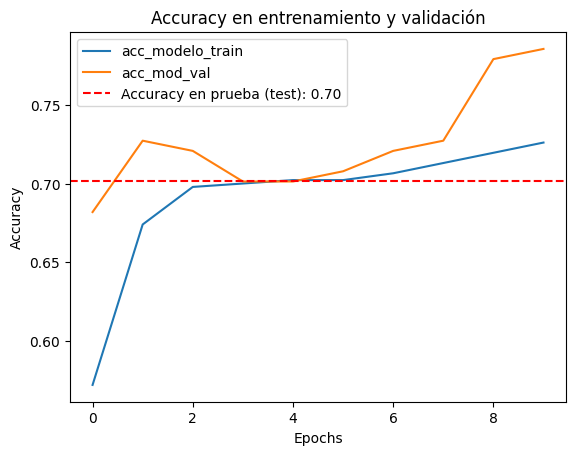

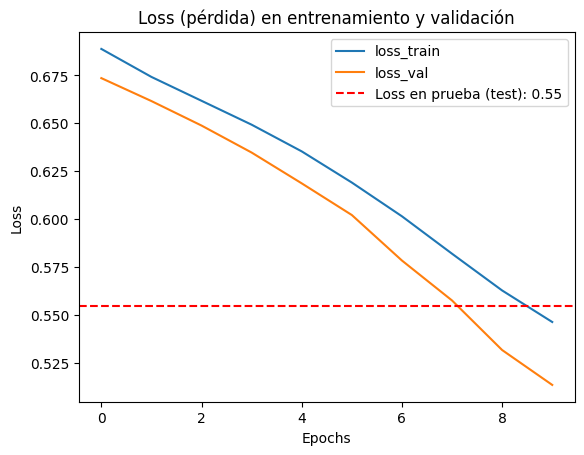

In [ ]:
# Gráfica del accuracy del modelo en train y test
loss_test, acc_test = model.evaluate(X_test_s, y_test, verbose=0)  #histori calcula el accuracy en cada epoca y ayuda a graficar iteracion por iteracion
plt.plot(history.history['accuracy'], label = "acc_modelo_train")
plt.plot(history.history['val_accuracy'], label = "acc_mod_val")
plt.axhline(y=acc_test, color='r', linestyle='--', label=f"Accuracy en prueba (test): {acc_test:.2f}")
plt.title("Accuracy en entrenamiento y validación")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
#un buen modelo es que el accuracy aumento que el error disminuya y con la matriz de confucion que las metricas sean buenas
# Gráfica de la pérdida en test y train
plt.plot(history.history['loss'], label = "loss_train")
plt.plot(history.history['val_loss'], label = "loss_val")
plt.axhline(y=loss_test, color='r', linestyle='--', label=f"Loss en prueba (test): {loss_test:.2f}")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss (pérdida) en entrenamiento y validación")
plt.legend()
plt.show()

***Interpretación:***

- En la gráfica del *Accuracy* se busca que a medida que evolucionen en las *epoch* se incremente este valor tanto en entrenamiento como en prueba. Un valor alto en entrenamiento y bajo en prueba indica posible *overfitting*.

- En la gráfica de la *pérdida* se busca que ambas gráficas sean decrecientes, lo que indicaria que a medida que se avanzan en las *epoch* se va minimizando la función *loss*.



Para hacer algunas predicciones y revisar la matriz de confusión podemos utilizar lo siguiente.

Primero, miramos las probabilidades

In [ ]:
predict = model.predict(X_test_s)
print(predict[0:10])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
[[0.38181293]
 [0.3881923 ]
 [0.2292791 ]
 [0.3402371 ]
 [0.2264286 ]
 [0.53231776]
 [0.40058178]
 [0.4028666 ]
 [0.70435387]
 [0.1256798 ]]


Calculamos las clases de acuerdo con las probabilidades y un umbral de 0.5

In [ ]:
y_predict = np.where(model.predict(X_test_s) > 0.5, 1, 0)
y_predict[0:10]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


array([[0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0]])

Ahora, construimos la matriz de confusión.

              precision    recall  f1-score   support

           0       0.71      0.91      0.80       101
           1       0.64      0.30      0.41        53

    accuracy                           0.70       154
   macro avg       0.68      0.61      0.61       154
weighted avg       0.69      0.70      0.67       154



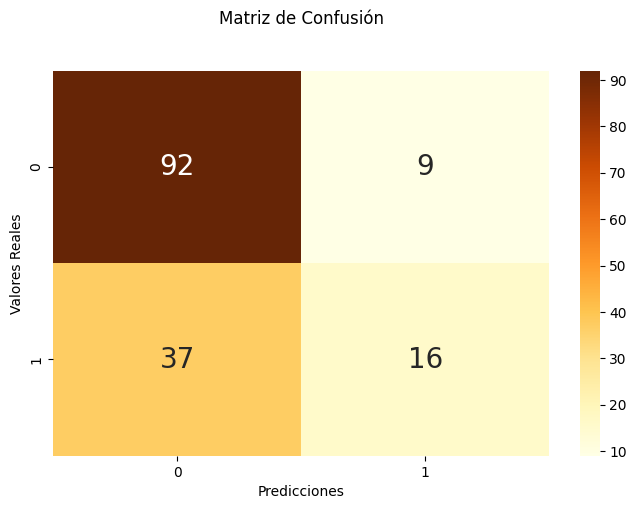

In [ ]:
plt.rcParams['figure.figsize'] = (8, 5)
from sklearn import metrics
cm = confusion_matrix(y_test, y_predict)
p = sns.heatmap(pd.DataFrame(cm),                   # data.frame
                annot=True,                         # colocar números de las cajitas
                annot_kws = {'size':20},            # tamaño de la letra
                cmap="YlOrBr",                       # color de la letra
                fmt='g')                            # para que salgan los número no : notación científica
plt.title('Matriz de Confusión', y=1.1)
plt.ylabel('Valores Reales')
plt.xlabel('Predicciones')

print(classification_report(y_test, y_predict))

Ahora, calculamos las métricas

In [ ]:
# métricas
metrics=["accuracy", "recall" , "specificity", "precision", "f1"]
values = [accuracy_score(y_test,y_predict),
          recall_score(y_test,y_predict),
          specificity_score(y_test,y_predict),
          precision_score(y_test,y_predict),
          f1_score(y_test,y_predict)]
print("Métricas \n")
evaluacion = pd.DataFrame(values , index = metrics , columns = ["modelo"])
evaluacion

Métricas 



,modelo
accuracy,0.727273
recall,0.509434
specificity,0.841584
precision,0.627907
f1,0.562500


# <FONT SIZE=5 COLOR="purple"> 3. Ejemplo de Clasificación : Crédito </FONT>

En este punto vamos a recordar como entrenar una red neuronal y las librerías que debemos usar.

Primero, revisaremos un poco sobre análisis exploratorio de los datos, luego entrenaremos el perceptrón multicapa y finalmente entrenaremos la red usando *keras* y *tensorflow*.

## <FONT SIZE=4 COLOR="blue"> 3.1 Contexto del problema </FONT>

***Objetivo del ejercicio***. Aplicar el modelo de clasificación para determinar cuando se aprueba a un cliente una tarjeta de crédito o no, dependiendo de las otras variables.

***Contexto de los datos***

Este ejercicio se basa en un conjunto de datos que se publicó originalmente junto con la quinta edición del libro *Análisis Econométrico* de William Greene.

Este libro tiene datos de tarjetas de crédito que se componen de una variable objetivo que es de naturaleza binaria (1 si se aprueba la solicitud de tarjeta de crédito, 0 si no) y algunas variables independientes sobre la demografía y el historial crediticio de los titulares de tarjetas de crédito.

Los datos para este trabajo están en *kaggle* en la siguiente *url*.

https://www.kaggle.com/datasets/dansbecker/aer-credit-card-data?select=AER_credit_card_data.csv

Sin embargo, se anexan los datos como ***credict3*** y este trabajo se va a desarrollar con esta base.

```python
url = "https://raw.githubusercontent.com/Fabian830348/Bases_Datos/master/credit3.csv"
```

Cada fila representa una solicitud de tarjeta de crédito, cada columna contiene los atributos del solicitante:

- *tarjeta*: variable ficticia, 1 si se aprueba la solicitud de tarjeta de crédito, 0 si no

- *informes*: número de informes despectivos importantes.

- *edad*: Edad n años más doceavos de un año.

- *ingreso*: ingreso anual (dividido por 10,000).

- *participación*: relación entre el gasto mensual de la tarjeta de crédito y el ingreso anual.

- *gasto*: gasto medio mensual con tarjeta de crédito.

- *propietario*: 1 si es dueño de su casa, 0 si alquila.

- *selfemp*: 1 si es autónomo, 0 si no.

- *dependientes*: 1 + número de dependientes.

- *meses*: Meses viviendo en la dirección actual.

- *majorcards*: número de las principales tarjetas de crédito que se tienen.

- activo: Número de cuentas de crédito activas.

Según Greene (2003, p. 952) los dependientes equivalen a 1 + número de dependientes. Eso se describe arriba. Los autores del paquete “AER” en R creen que es el número de dependientes.

Algunas precisiones sobre las variables

- *Los informes promedio* (es decir, el número promedio de informes despectivos importantes) de los solicitantes que fueron aprobados es menor que el de los solicitantes que no fueron aprobados.

- *El ingreso promedio* (es decir, el ingreso anual promedio dividido por 10,000) de los solicitantes que fueron aprobados es más alto que el de los solicitantes que no fueron aprobados.

- *La participación promedio* (es decir, la relación promedio entre el gasto mensual de la tarjeta de crédito y el ingreso anual) de los solicitantes que fueron aprobados es más alta que la de los solicitantes que no fueron aprobados.

- *El gasto promedio* (es decir, el gasto mensual promedio con tarjeta de crédito) de los solicitantes que fueron aprobados es más alto que el de los solicitantes que no fueron aprobados.

- *El promedio de dependientes*(es decir, el número promedio de dependientes) de los solicitantes que fueron aprobados es menor que el de los solicitantes que no fueron aprobados.

- *El promedio de tarjetas principales (es decir, el número promedio de las principales tarjetas de crédito) de los solicitantes que fueron aprobados es más alto que el de los solicitantes que no fueron aprobados.


## <FONT SIZE=4 COLOR="blue"> 3.2 Importar los datos </FONT>










In [ ]:
# cargar los datos que están la dirección del github
url = "https://raw.githubusercontent.com/Fabian830348/Bases_Datos/master/datos_credito.csv"
credito = pd.read_csv(url, na_values=[" "])

## <FONT SIZE=4 COLOR="blue"> 3.3 Exploración de los datos </FONT>

En esta parte se hará la exploración de los datos.

- Siga las instrucciones y escriba el código correspondiente

In [ ]:
# tamaño de los datos
credito.shape

(1310, 12)

In [ ]:
# cabeza y cola de los datos
credito.head(5)

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,1,0,37.66667,4.5200,0.033270,124.983300,1,0,3,54,1,12
1,1,0,33.25000,2.4200,0.005217,9.854167,0,0,3,34,1,13
2,1,0,33.66667,4.5000,0.004156,15.000000,1,0,4,58,1,5
3,1,0,30.50000,2.5400,0.065214,137.869200,0,0,0,25,1,7
4,1,0,32.16667,9.7867,0.067051,546.503300,1,0,2,64,1,5


In [ ]:
# nombre de las variables
credito.columns

Index(['card', 'reports', 'age', 'income', 'share', 'expenditure', 'owner',
       'selfemp', 'dependents', 'months', 'majorcards', 'active'],
      dtype='object')

In [ ]:
# Verificación de la existencia de datos faltantes y tipología de las variables
credito.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1310 entries, 0 to 1309
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   card         1310 non-null   int64  
 1   reports      1310 non-null   int64  
 2   age          1310 non-null   float64
 3   income       1310 non-null   float64
 4   share        1310 non-null   float64
 5   expenditure  1310 non-null   float64
 6   owner        1310 non-null   int64  
 7   selfemp      1310 non-null   int64  
 8   dependents   1310 non-null   int64  
 9   months       1310 non-null   int64  
 10  majorcards   1310 non-null   int64  
 11  active       1310 non-null   int64  
dtypes: float64(4), int64(8)
memory usage: 122.9 KB


In [ ]:
# descripción estadística de los datos
credito.describe()

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
count,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000
mean,0.775573,0.458779,33.374873,3.368444,0.068644,184.996730,0.440458,0.069466,0.993130,55.111450,0.817557,6.993130
std,0.417364,1.349327,9.886538,1.698234,0.094828,272.843418,0.496632,0.254341,1.248051,66.229211,0.386356,6.302954
min,0.000000,0.000000,18.166670,0.210000,0.000109,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,25.416670,2.240625,0.002272,4.583333,0.000000,0.000000,0.000000,12.000000,1.000000,2.000000
50%,1.000000,0.000000,31.250000,2.900000,0.038775,101.231650,0.000000,0.000000,0.500000,30.000000,1.000000,6.000000
75%,1.000000,0.000000,39.416670,4.000000,0.093396,248.859150,1.000000,0.000000,2.000000,72.000000,1.000000,11.000000
max,1.000000,14.000000,83.500000,13.500000,0.906320,3099.505000,1.000000,1.000000,6.000000,540.000000,1.000000,46.000000


In [ ]:
# revisamos los valores de la variable card
# credit.card // credit["card"]
credito.card.value_counts()

,count
card,
1,1016
0,294


Vamos a poder todo en un solo bloque de código

In [ ]:
#variable objetivo
y = credito["card"]
# variables predictoras
X = credito.drop("card", axis=1)

# dividir en los tres conjuntos
# 1. Dividimos en entrenamiento (60%) y el otro (40%) lo denominamos temporal ya que se va a volver a dividir
X_train, X_temp, y_train, y_temp = train_test_split(X,                        # variables predictoras
                                                    y,                        # variable de respuesta
                                                    random_state = 0,         # semilla para que al ejecutar siempre de igual
                                                    stratify=y,               # estratificamos con respecto a y (asegura que se mantenga la proporción de clases en y)
                                                    test_size = 0.4)          # tamaño del conjunto de prueba

X_val, X_test, y_val, y_test = train_test_split(X_temp,                       # variables predictoras
                                                y_temp,                       # variable de respuesta
                                                random_state = 0,             # semilla para que al ejecutar siempre de igual
                                                stratify=y_temp,              # estratificamos con respecto a y_temp
                                                test_size = 0.5)              # tamaño del conjunto de prueba


# variables numéricas de predicción
variables_num = credito.drop(["card","owner","selfemp"], axis =1).columns
variables_num

# variables categóricas de predicción (yes/no)
variables_cat = ["owner", "selfemp"]
variables_cat

# Definitmos el preprocesador de escalamiento
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), variables_num),
    ('cat', "passthrough", variables_cat) #passthrough
])

# aplicamos el preprocesador

X_train_s = preprocessor.fit_transform(X_train)
X_val_s = preprocessor.transform(X_val)
X_test_s = preprocessor.transform(X_test)

# convertir a arreglos densos. funciona mejor en Tensorflow

X_train_s = X_train_s.astype('float32')
X_val_s = X_val_s.astype('float32')
X_test_s = X_test_s.astype('float32')

# definir el modelo y
model = Sequential()

# Definimos la arquitectura de la red:problema de clasificación binaria
model.add(Dense(16, input_dim=X_train_s.shape[1], activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# compilar el modelo
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

#definir una parada tremprana.
early_stopping = EarlyStopping(monitor="val_loss",
                               patience=3,
                               restore_best_weights=True)


# Entrenar el modelo usando el conjunto de validación explícitamente
history = model.fit(X_train_s,
                    y_train,
                    epochs=200,
                    validation_data=(X_val_s, y_val),
                    verbose=0,
                    callbacks=[early_stopping, TqdmCallback()])

# 5. Evaluar el modelo
print("\n--- Evaluación ---")
print("Pérdida y Accuracy en entrenamiento:", model.evaluate(X_train_s, y_train))
print("Pérdida y Accuracy en validación:  ", model.evaluate(X_val_s, y_val))
print("Pérdida y Accuracy en prueba (test):", model.evaluate(X_test_s, y_test))


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]


--- Evaluación ---
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9567 - loss: 0.1197 
Pérdida y Accuracy en entrenamiento: [0.11968030035495758, 0.9567430019378662]
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9466 - loss: 0.1292 
Pérdida y Accuracy en validación:   [0.12920621037483215, 0.9465649127960205]
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9160 - loss: 0.1811 
Pérdida y Accuracy en prueba (test): [0.1810566633939743, 0.9160305261611938]


In [ ]:
print("Épocas ejecutadas:", len(history.history["loss"]))

Épocas ejecutadas: 103


In [ ]:
# crear una función de evaluación # crear para guardarla
def evaluar_modelo_binario(model, X_test_s, y_test, umbral=0.5):

    # Probabilidades
    y_prob = model.predict(X_test_s)

    print("Primeras 10 probabilidades:")
    print(y_prob[0:10])

    # Predicciones 0/1
    y_predict = np.where(y_prob > umbral, 1, 0)

    print("\nPrimeras 10 clases predichas:")
    print(y_predict[0:10])

    # Matriz de confusión

    print("\nMatriz de Confusión:")

    cm = confusion_matrix(y_test, y_predict)

    plt.rcParams['figure.figsize'] = (8, 5)

    sns.heatmap(
        pd.DataFrame(cm),
        annot=True,
        annot_kws={'size': 20},
        cmap="YlOrBr",
        fmt='g'
    )

    plt.title('Matriz de Confusión', y=1.1)
    plt.ylabel('Valores Reales')
    plt.xlabel('Predicciones')
    plt.show()

    # Métricas
    print("\nMétricas:")

    metricas = ["accuracy", "recall", "specificity", "precision", "f1"]

    values = [
        accuracy_score(y_test, y_predict),
        recall_score(y_test, y_predict),
        specificity_score(y_test, y_predict),
        precision_score(y_test, y_predict),
        f1_score(y_test, y_predict)
    ]

    evaluacion = pd.DataFrame(
        values,
        index=metricas,
        columns=["modelo"]
    )

    return evaluacion


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Primeras 10 probabilidades:
[[0.27177387]
 [0.9769172 ]
 [0.9999992 ]
 [0.5285692 ]
 [0.2650922 ]
 [0.88802576]
 [0.9114645 ]
 [0.75968325]
 [0.99836314]
 [0.9999243 ]]

Primeras 10 clases predichas:
[[0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]]

Matriz de Confusión:


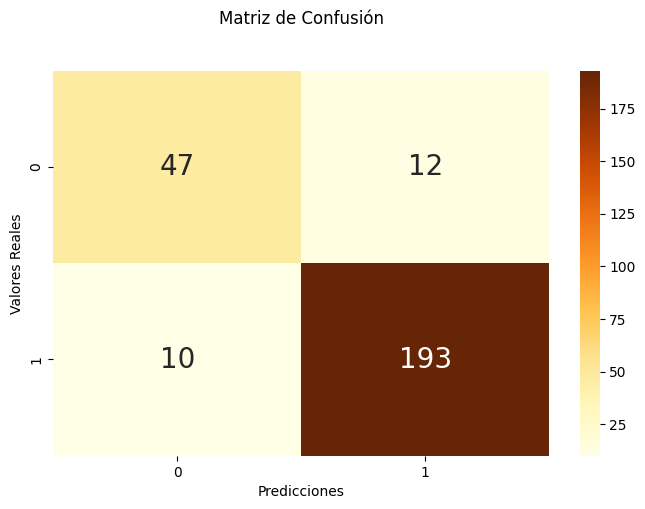


Métricas:


,modelo
accuracy,0.916031
recall,0.950739
specificity,0.796610
precision,0.941463
f1,0.946078


In [ ]:
# evaluar el modelo
evaluacion = evaluar_modelo_binario(model, X_test_s, y_test)
evaluacion

In [ ]:
# función para las gráficas
def graficar_historial(history, model, X_test_s, y_test):

    # evaluar en test
    loss_test, acc_test = model.evaluate(
        X_test_s,
        y_test,
        verbose=0
    )

    # tamaño general
    plt.figure(figsize=(14,5))

    # =========================
    # Gráfica Accuracy
    # =========================
    plt.subplot(1, 2, 1)

    plt.plot(
        history.history['accuracy'],
        label="acc_train"
    )

    plt.plot(
        history.history['val_accuracy'],
        label="acc_val"
    )

    plt.axhline(
        y=acc_test,
        color='r',
        linestyle='--',
        label=f"acc_test = {acc_test:.2f}"
    )

    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # =========================
    # Gráfica Loss
    # =========================
    plt.subplot(1, 2, 2)

    plt.plot(
        history.history['loss'],
        label="loss_train"
    )

    plt.plot(
        history.history['val_loss'],
        label="loss_val"
    )

    plt.axhline(
        y=loss_test,
        color='r',
        linestyle='--',
        label=f"loss_test = {loss_test:.2f}"
    )

    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

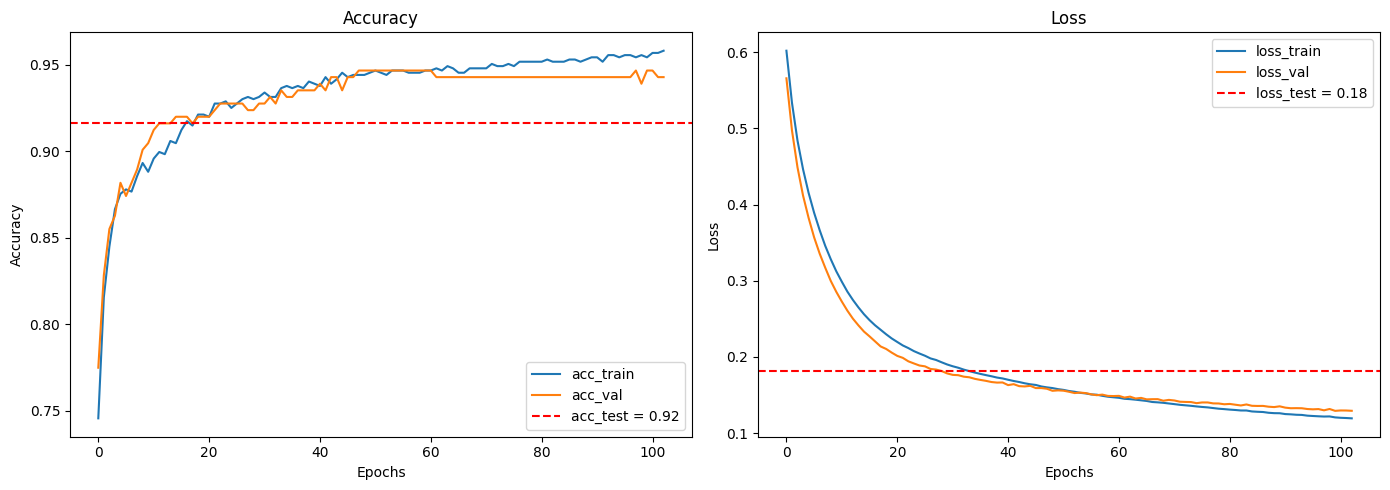

In [ ]:
# graficar historial
graficar_historial(history, model, X_test_s, y_test)

**Ejercicio**

Analizar los resultados

# <FONT SIZE=5 COLOR="purple"> 4. Ejemplo de los números </FONT>

En este ejercicio vamos a realizar el proceso de clasificación multicase con el conjunto de datos mnist (este se trabajó en k-means)


Primero, importaremos los datos de la librería keras.datasets

In [ ]:
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f'Número de muestras de entrenamiento: {len(X_train)}')
print(f'Número de muestras de validación: {len(X_test)}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Número de muestras de entrenamiento: 60000
Número de muestras de validación: 10000


Visualizando Imágenes de MNIST

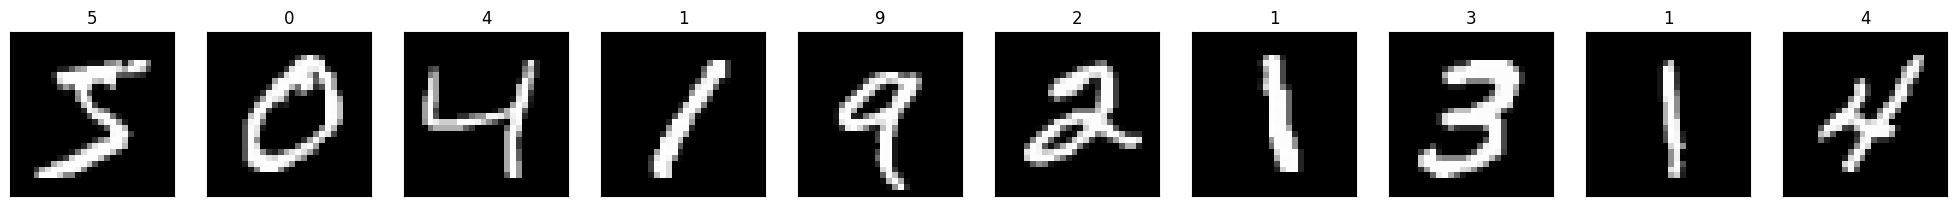

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

SAMPLE_SIZE = 10

# Plot the images in the sample
figure = plt.figure(figsize=(25, 25))

for sample_index in range(SAMPLE_SIZE):
    ax = figure.add_subplot(1, SAMPLE_SIZE, sample_index + 1, xticks=[], yticks=[])
    ax.imshow(X_train[sample_index], cmap='gray')
    ax.set_title(y_train[sample_index])

- En el gráfico de arriba observamos varios registros de los datos.

- Entre los ejemplos en la muestra, podemos ver que varios corresponden al mismo número, como el 4 y el 1.

- También podemos detallar que, a pesar de que describen al mismo número, tienen diferencias sutiles.

- El trabajo de nuestra red, por consiguiente, será capturar estos matices con el fin de predecir el número dibujado en cada imagen.

Imagen Detallada

Solo para entender mejor lo que la computadora realmente ve, miremos una de éstas imágenes en su forma real: Una matriz.

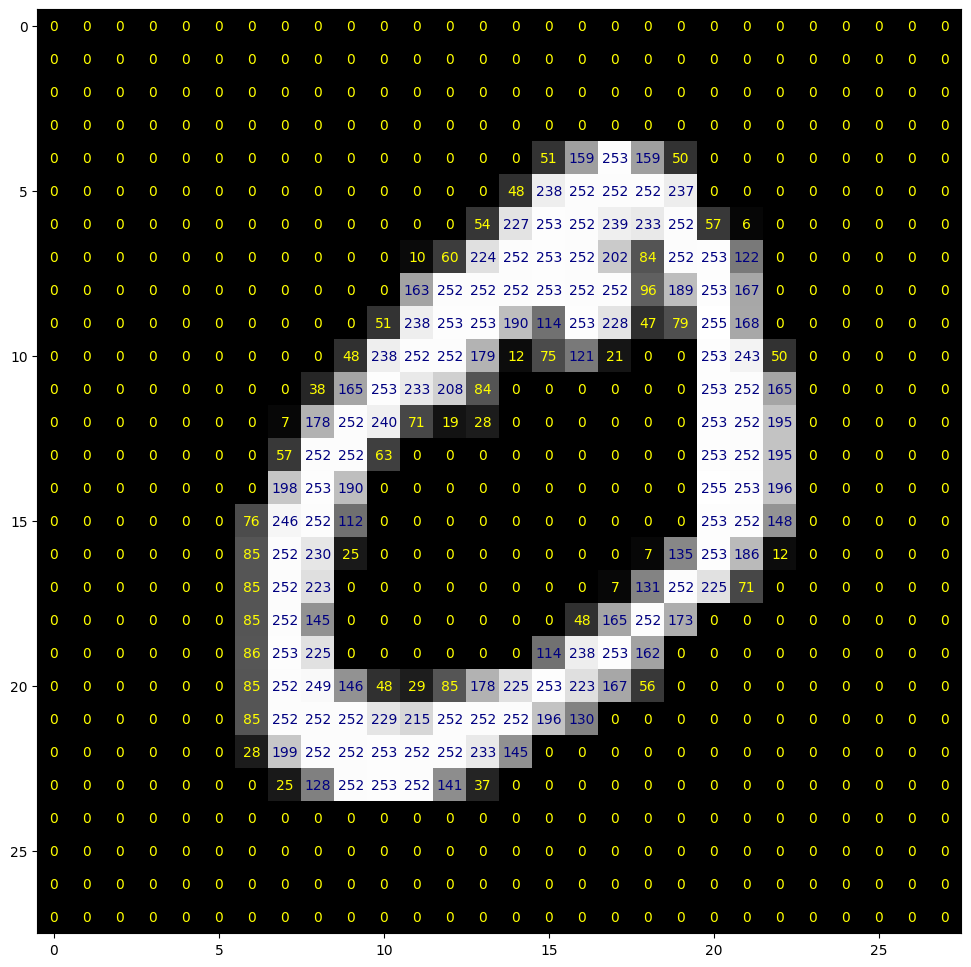

In [ ]:
def visualize_input(image, ax):
    ax.imshow(image, cmap='gray')
    width, height = image.shape
    threshold = image.max() / 2.5

    for x in range(width):
        for y in range(height):
            pixel_value = image[x][y]
            ax.annotate(f'{round(pixel_value, 2)}',
                        xy=(y, x),
                       horizontalalignment='center',
                       verticalalignment='center',
                       color='yellow' if pixel_value < threshold else 'navy')

SAMPLE_INDEX = 1
figure = plt.figure(figsize=(12, 12))
ax = figure.add_subplot(111)
visualize_input(X_train[SAMPLE_INDEX], ax)

- Los números subyacentes son lo que la computadora realmente ve.

- Así, el trabajo del MLP será darle sentido a este montón de números y, de alguna forma, entender que se trata de un 0.

Reescalando las Imágenes

Una buena manera de reescalar una imagen es dividir el valor de cada pixel entre 255, el número más alto que pueden tomar en el espacio de color RGB. Esto hará que cada pixel esté contenido en el rango [0, 1].

In [ ]:
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

Codificando Las Etiquetas como Vectores One-hot.

Con la finalidad de romper alguna posible parcialidad con relación al orden de las etiquetas (por ejemplo, que 0 sea interpretado como mejor que 1, 1 mejor que 2, y así sucesivamente), podemos codificar cada etiqueta como un vector one-hot.

Esto quiere decir que cada número será convertido a un vector de sólo ceros, a excepción del índice que representa al número, donde habrá un 1.

0 es representado por [1, 0, 0, 0, 0, 0, 0, 0, 0, 0].

1 es representado por [0, 1, 0, 0, 0, 0, 0, 0, 0, 0].

2 es representado por [0, 0, 2, 0, 0, 0, 0, 0, 0, 0].

.

.

.

9 es representado por [0, 0, 0, 0, 0, 0, 0, 0, 0, 1].

In [ ]:
pip install keras

In [ ]:
pip install np_utils

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for np_utils: filename=np_utils-0.6.0-py3-none-any.whl size=56437 sha256=7a6d30f43eb70675868ead2674e77bd00b2a636b1db1bf650f4700287955849b
  Stored in directory: /root/.cache/pip/wheels/dd/bd/f5/0975fe5179dfa2f996b436596b159824432fb3c1ca74bcf43e
Successfully built np_utils


In [ ]:
from keras.utils import to_categorical

In [ ]:
from keras import utils

In [ ]:
print('Sample of original labels:')
print(y_train[:10])

Numero_etiquetas = 10
y_train = utils.to_categorical(y_train, Numero_etiquetas )
y_test = utils.to_categorical(y_test, Numero_etiquetas )

print('Sample of one-hot encoded labels:')
print(y_train[:10])

Sample of original labels:
[5 0 4 1 9 2 1 3 1 4]
Sample of one-hot encoded labels:
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


Arquitectura del Modelo

Éste es el aspecto principal. Definamos una red neuronal básica de 3 capas utilizando **Sequential** de Keras.

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten

# Model definition
model = Sequential()

# se deben aplastar las matrices en arreglos
model.add(Flatten(input_shape=X_train.shape[1:])) #flatten aplasta para que lo pueda leer porque es un matriz tiene que ser lineal

# arquitectura de la red
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))

# la última capa se define como el número de etiquetas para clasificar y cuando son más de dos, se usa Softmax
model.add(Dense(Numero_etiquetas, activation='softmax'))

# Model summarization
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

- tenemos 669.706 parametros para esta red.

- Son sólo imágenes de 28x28

- Esto nos da a entender uno de los grandes problemas de los MLPs: Escalabilidad.

**Compilando el Modelo**

Ahora que el modelo está definido, podemos compilarlo. Como optimizador, usaremos Adam, el cual es un buen algoritmo por defecto.

La métrica escogida para medir nuestro progreso es la precisión (accuracy).

In [ ]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

Entrenando el Modelo

Entrenemos nuestro MLP. Guardaremos únicamente el modelo con el mejor accuracy.

In [ ]:
# Entrenar el modelo usando el conjunto de validación explícitamente
history = model.fit(X_train,
                    y_train,
                    epochs=10,
                    batch_size=256,
                    validation_split=0.2,
                    verbose=0,
                    callbacks=[TqdmCallback(verbose=1)])

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Graficando el Historial del Loss y el Accuracy

Graficar el progreso del loss y el accuracy es una buena práctica para detectar posibles señales de underfitting u overfitting.

In [ ]:
# evaluación del modelo
score = model.evaluate(X_test, y_test, verbose=0)
score

[0.0647771880030632, 0.9829999804496765]

In [ ]:
y_test

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

diferencia entre max y ar max es que max es el valor mas grande y el argmax es donde se obtiene el valor maximo

In [ ]:
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)
y_real = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_real, y_pred)
cm

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


array([[ 973,    2,    1,    0,    0,    0,    2,    0,    1,    1],
       [   0, 1122,    3,    2,    0,    0,    2,    0,    6,    0],
       [   0,    0, 1019,    4,    1,    0,    2,    2,    4,    0],
       [   0,    0,    3,  999,    0,    2,    0,    3,    1,    2],
       [   2,    1,    5,    1,  952,    0,    6,    1,    1,   13],
       [   2,    0,    0,    9,    1,  874,    2,    1,    2,    1],
       [   2,    2,    0,    1,    1,    4,  947,    0,    1,    0],
       [   1,    4,   10,    1,    0,    0,    0, 1005,    1,    6],
       [   0,    1,    3,    4,    1,    5,    1,    3,  950,    6],
       [   2,    2,    0,    2,    4,    4,    2,    1,    3,  989]])

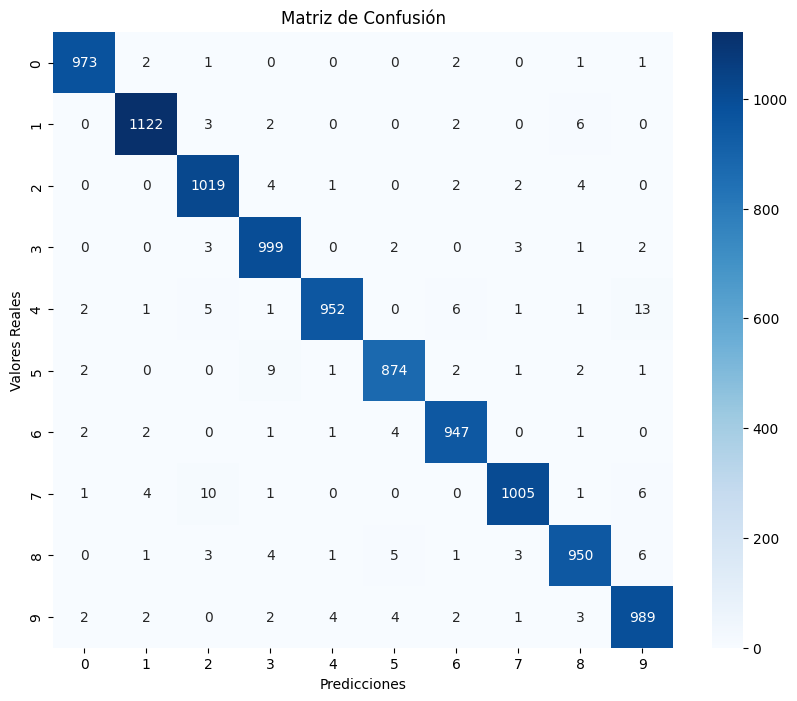

In [ ]:
# gráfica de la matriz de confusión
plt.figure(figsize=(10,8))

sns.heatmap(
    pd.DataFrame(cm),
    annot=True,
    fmt='g',
    cmap='Blues'
)

plt.title("Matriz de Confusión")
plt.ylabel("Valores Reales")
plt.xlabel("Predicciones")

plt.show()

In [ ]:
# clasification report
print(classification_report(y_real, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.98      1032
           3       0.98      0.99      0.98      1010
           4       0.99      0.97      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.99      0.99       958
           7       0.99      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.97      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


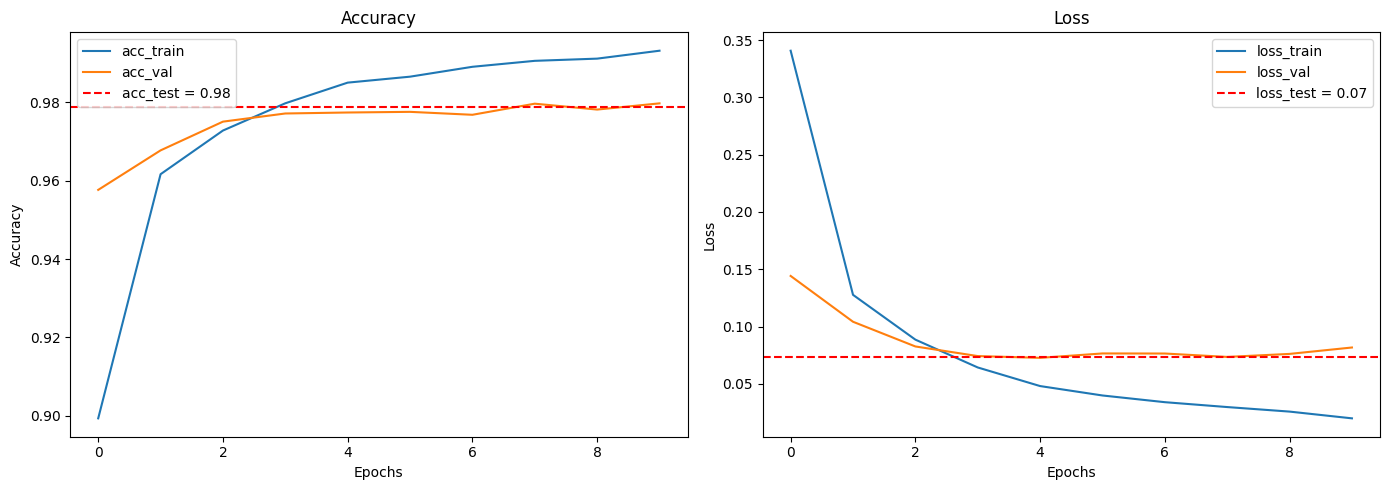

In [ ]:
graficar_historial(history, model, X_test, y_test)

# <FONT SIZE=5 COLOR="purple"> 5. Ejercicio </FONT>

Considere el conjunto de datos de vinos:

```python
https://raw.githubusercontent.com/MFuchs1989/Datasets-and-Miscellaneous/main/datasets/winequality.csv
```

1. Cargar los datos
2. ¿Qué significan las variables?
3. Haga una breve exploración de los datos
4. Aplicar los modelos de:

  - Perceptron (sklearn)
  - MLP (sklearn)
  - Redes con Tensorflow.keras
  - Random Forest

Para el problema de clasificación del tipo de vino

Compare los modelos obtenidos.


hacer modelo con perceptron y mlp y tens of flow y pytorch

In [ ]:
url2 ="https://raw.githubusercontent.com/MFuchs1989/Datasets-and-Miscellaneous/main/datasets/winequality.csv"

In [ ]:
df = pd.read_csv(url2)
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
